# MedXpertQA — Análisis Exploratorio de Datos (EDA)
**TFG · Paso 1 · Tarea C**

Este cuaderno ejecuta, de forma narrada y reproducible, el análisis exploratorio del
benchmark **MedXpertQA** (ICML 2025). Toda la lógica vive en `src/eda.py`; aquí se
invoca paso a paso mostrando tablas y figuras *inline*. Cada cifra procede de una celda
ejecutada; las tablas se guardan en `outputs/tables/` y las figuras (300 dpi) en
`outputs/figures/`.

**Contenido**
- 0. Esquema real e integridad
- C.1 Metadatos y estructura
- C.2 Chequeo de sesgos (posición de la respuesta)
- C.3 Análisis del texto (longitud y casi-duplicados)
- C.4 Componente visual (solo MM)
- C.5 Relación texto ↔ imagen (solo MM)
- Informe y *data card*

> Requisito previo: haber ejecutado `python src/download.py` (datos) y, opcionalmente,
> `python src/verify.py` (integridad). Las cachés de cómputo pesado las crea `src/eda.py`.

In [1]:
import sys
from pathlib import Path

# Localiza src/ tanto si el notebook se ejecuta desde la raíz como desde notebooks/
cwd = Path.cwd()
src = next((c / "src" for c in (cwd, cwd.parent) if (c / "src" / "eda.py").exists()), None)
assert src is not None, "No se encuentra src/eda.py"
sys.path.insert(0, str(src))

import pandas as pd
import eda

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
%matplotlib inline
eda.setup_style()

dfs = eda.load_all()
{k: len(v) for k, v in dfs.items()}

{'MM': 2000, 'Text': 2450}

## 0. Esquema real e integridad

El esquema se confirmó por inspección directa (no se asumió). Puntos clave: `options` es un
**diccionario** (`A–E` en MM, `A–J` en Text), `label` es un **string** de una letra, y las
imágenes vienen en el campo **`images`** como lista de *basenames*. La integridad completa
(recuentos 2000/2450, correspondencia imagen↔archivo exacta, 0 corruptas, IDs únicos,
`label`∈`options` al 100 %) está verificada en `outputs/report/00_integridad.md`.

In [2]:
mm0 = dfs["MM"].iloc[0]
print("Claves MM :", list(dfs["MM"].columns))
print("Claves Text:", list(dfs["Text"].columns))
print("Ejemplo id :", mm0["id"], "| label:", mm0["label"], "| n_options:", mm0["n_options"],
      "| images:", mm0["images"])
print("options    :", mm0["options"])

Claves MM : ['id', 'question', 'options', 'label', 'images', 'medical_task', 'body_system', 'question_type', 'n_options', 'n_labels', 'n_images']
Claves Text: ['id', 'question', 'options', 'label', 'medical_task', 'body_system', 'question_type', 'n_options', 'n_labels']
Ejemplo id : MM-0 | label: A | n_options: 5 | images: ['MM-0-a.jpeg', 'MM-0-b.jpeg']
options    : {'A': 'Lateral collateral ligament complex repair or reconstruction', 'B': 'Capsular plication', 'C': 'Radial head replacement', 'D': 'Radial head ORIF', 'E': 'Medial collateral ligament complex reconstruction'}


## C.1 — Metadatos y estructura

Distribución de los tres ejes de metadatos por subconjunto, tablas cruzadas y verificación
de la estructura de opciones/respuestas.

,MM_n,Text_n,MM_pct,Text_pct
body_system,,,,
Skeletal,491,355,24.55,14.49
Cardiovascular,320,306,16.00,12.49
Nervous,231,386,11.55,15.76
Digestive,168,274,8.40,11.18
Respiratory,192,193,9.60,7.88
Reproductive,98,201,4.90,8.20
Integumentary,225,48,11.25,1.96
Endocrine,74,176,3.70,7.18
Muscular,46,177,2.30,7.22


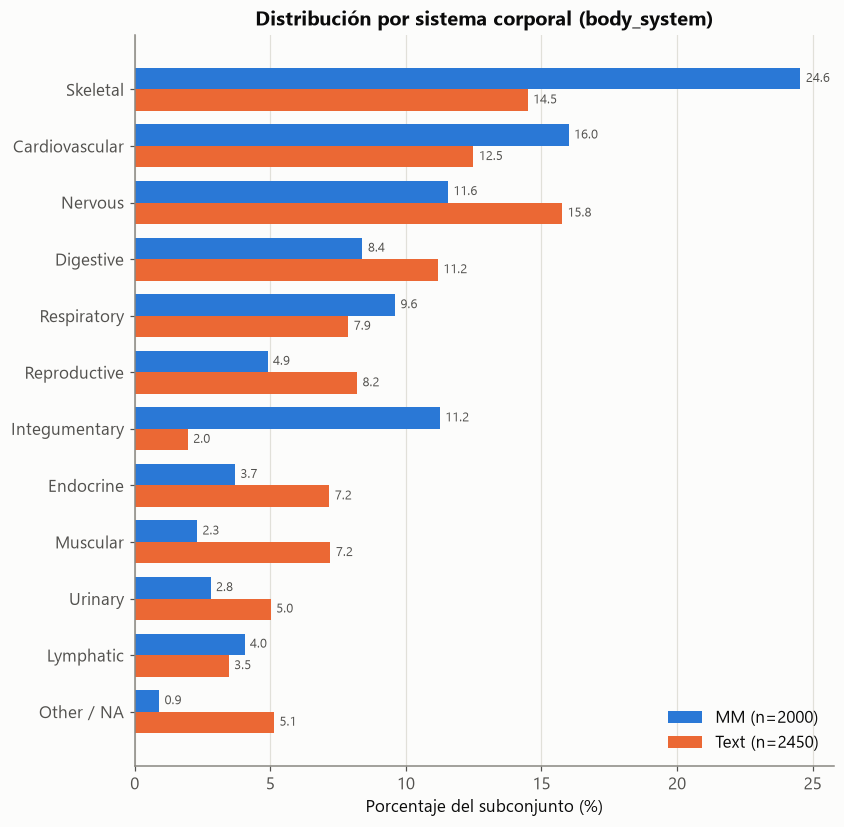

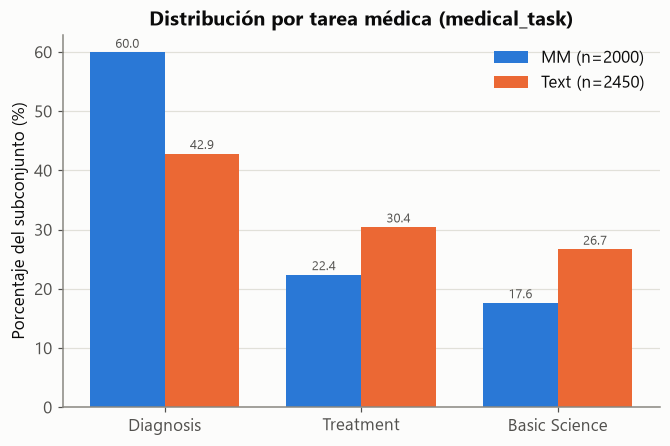

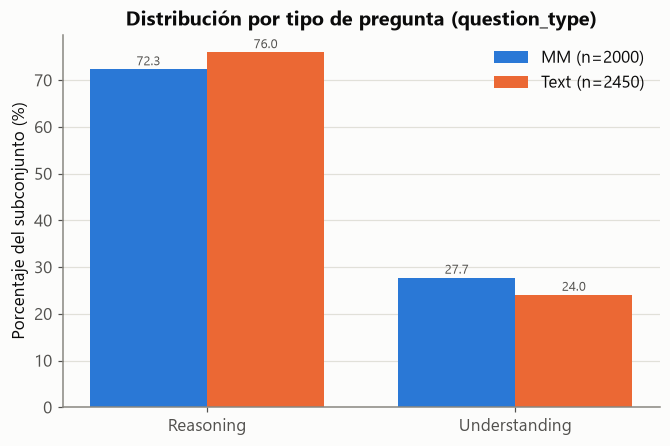

In [3]:
res_c1 = eda.c1_metadata_distributions(dfs)
res_c1["body_system"]

In [4]:
display(res_c1["medical_task"])
display(res_c1["question_type"])

,MM_n,Text_n,MM_pct,Text_pct
medical_task,,,,
Diagnosis,1199,1050,59.95,42.86
Treatment,448,746,22.40,30.45
Basic Science,353,654,17.65,26.69


,MM_n,Text_n,MM_pct,Text_pct
question_type,,,,
Reasoning,1446,1861,72.3,75.96
Understanding,554,589,27.7,24.04


Cuadrantes question_type × medical_task (MM):


medical_task,Basic Science,Diagnosis,Treatment
question_type,,,
Reasoning,218,811,417
Understanding,135,388,31


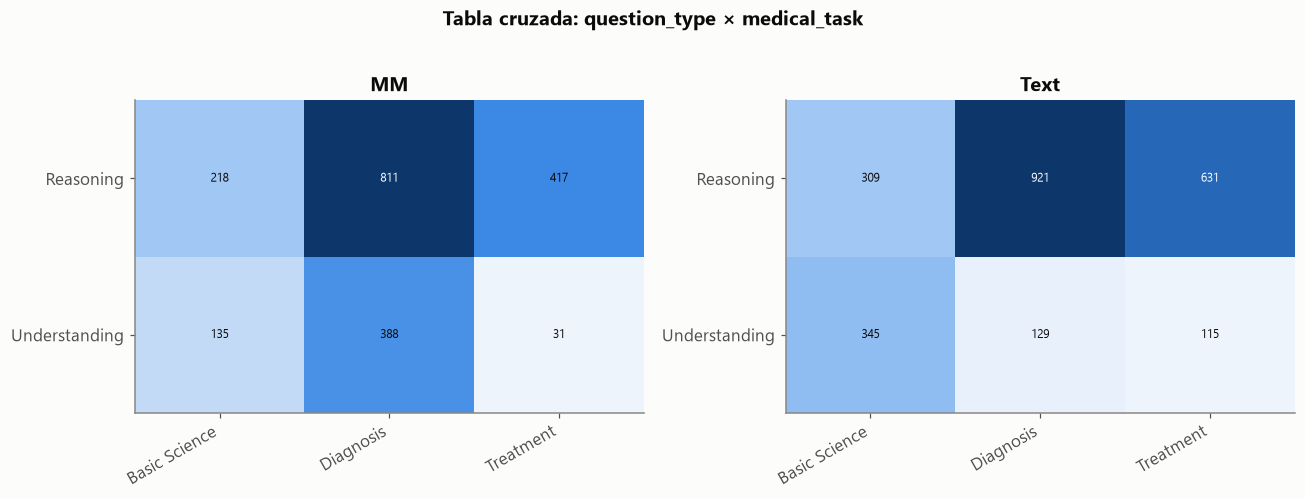

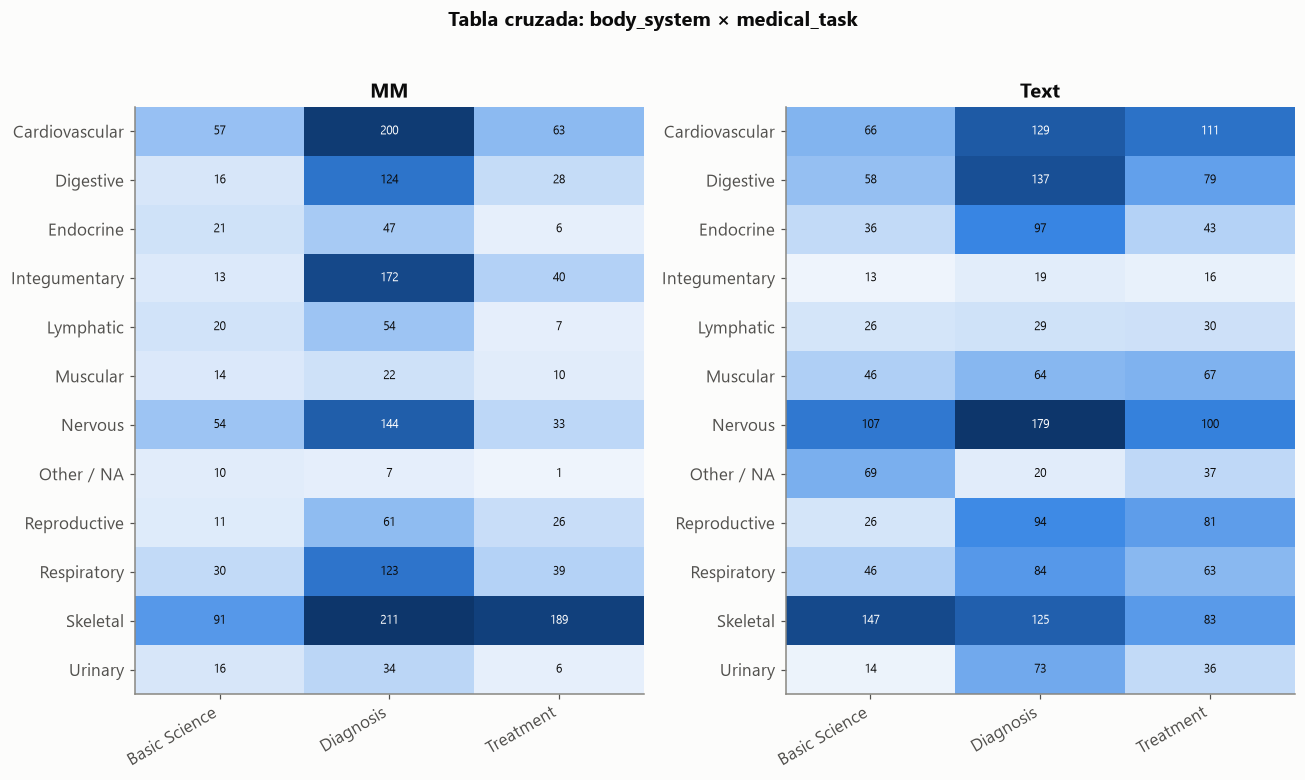

In [5]:
res_c1x = eda.c1_crosstabs(dfs)
print("Cuadrantes question_type × medical_task (MM):")
res_c1x[("question_type", "medical_task", "MM")]

In [6]:
res_c1o = eda.c1_options_answers(dfs)
res_c1o["table"]

,subconjunto,n_opciones_esperado,n_opciones_valores,todas_con_n_esperado,n_respuestas_correctas_valores,siempre_1_correcta
0,MM,5,"{""5"": 2000}",True,"{""1"": 2000}",True
1,Text,10,"{""10"": 2450}",True,"{""1"": 2450}",True


**Lectura C.1.** `body_system` cubre 12 categorías; MM está sesgado hacia especialidades
visuales (*Skeletal*, *Integumentary*) y Text hacia *Nervous*. *Diagnosis* es la tarea
mayoritaria y **Reasoning** el tipo dominante: el benchmark prioriza razonamiento clínico.
La estructura es de **opción única** (siempre 1 correcta), con 5 opciones en MM y 10 en Text.

## C.2 — Chequeo de sesgos (posición de la respuesta)

¿Está balanceada la letra correcta? Se comparan las baselines de **azar** y de **mayoría**
(responder siempre la letra más frecuente) y se contrasta la uniformidad con un test χ².

,subconjunto,n_opciones,n,baseline_azar,baseline_mayoria,letra_mayoritaria,chi2,p_valor,uniforme_p>0.05
0,MM,5,2000,0.2,0.2120,E,2.815,0.589246,True
1,Text,10,2450,0.1,0.1073,E,6.318,0.707680,True


letra,A,B,C,D,E,F,G,H,I,J
MM,399.0,408.0,383.0,386.0,424.0,NaN,NaN,NaN,NaN,NaN
Text,241.0,246.0,239.0,244.0,263.0,243.0,263.0,222.0,232.0,257.0


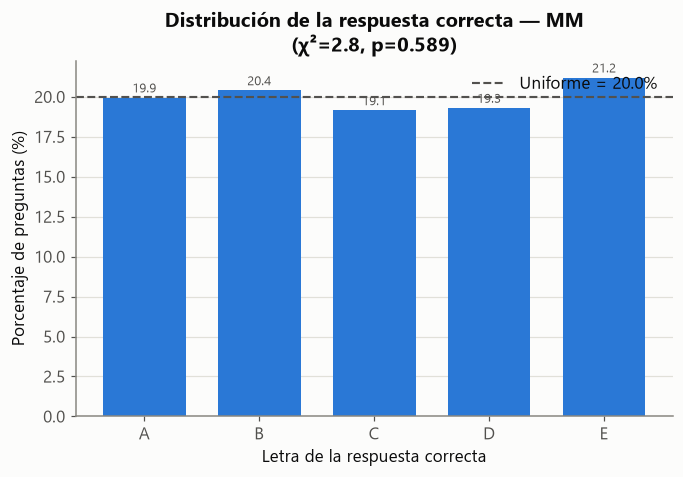

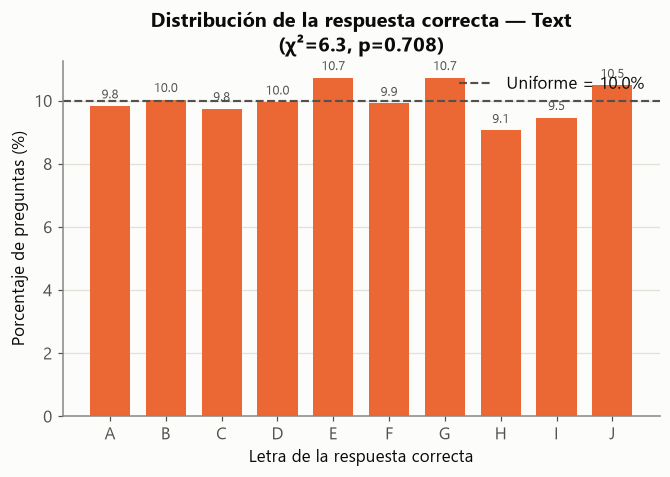

In [7]:
res_c2 = eda.c2_label_bias(dfs)
display(res_c2["baselines"])
res_c2["distribution"].T

**Lectura C.2.** No hay sesgo posicional explotable: la baseline de mayoría apenas supera a
la de azar y el test χ² no permite rechazar la uniformidad. Cualquier modelo debe superar
con holgura estas baselines para ser informativo.

## C.3 — Análisis del texto

Longitud del enunciado (caracteres, palabras y **tokens** con `cl100k_base` y, si está
disponible, con el tokenizador de **Qwen2.5-VL**) por subconjunto y tipo de pregunta, y
detección de casi-duplicados (hash exacto + TF-IDF/coseno) para el control de contaminación.

,chars_mean,chars_std,chars_min,chars_median,chars_max,chars_p95,words_mean,words_std,words_min,words_median,words_max,words_p95,tok_cl100k_mean,tok_cl100k_std,tok_cl100k_min,...,words_full_median,words_full_max,words_full_p95,tok_cl100k_full_mean,tok_cl100k_full_std,tok_cl100k_full_min,tok_cl100k_full_median,tok_cl100k_full_max,tok_cl100k_full_p95,tok_qwen_full_mean,tok_qwen_full_std,tok_qwen_full_min,tok_qwen_full_median,tok_qwen_full_max,tok_qwen_full_p95
subconjunto,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MM,647.9,340.5,107,640.0,2096,1185.0,97.4,52.3,17,96.0,359,180.0,152.6,81.9,36,...,118.0,449,211.0,197.3,90.2,61,187.0,708,345.0,201.6,94.6,61,189.0,709,354.0
Text,1093.9,402.3,191,1085.5,4527,1724.6,163.4,65.1,30,159.0,728,268.0,263.2,103.8,77,...,210.0,1216,374.0,371.1,132.2,127,355.0,1725,589.0,379.4,137.2,129,362.0,1816,601.5


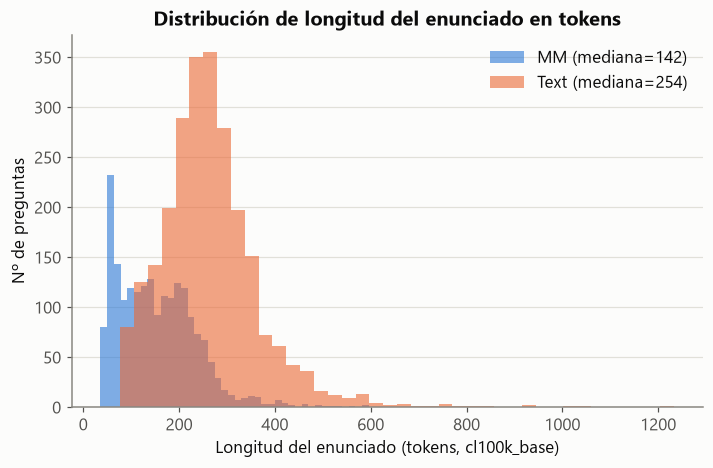

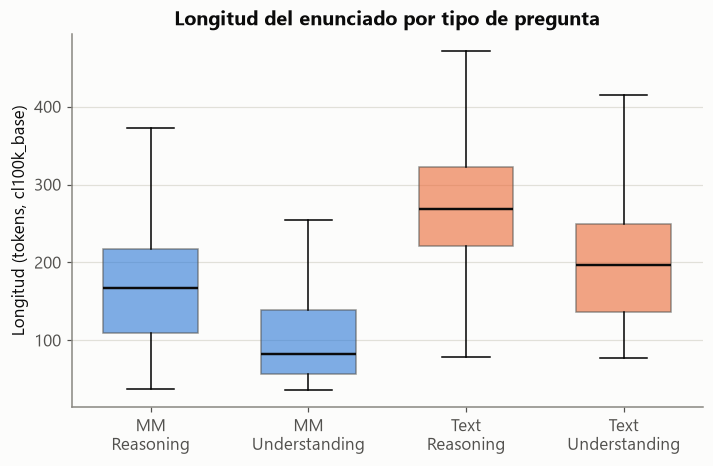

In [8]:
res_c3 = eda.c3_text_lengths(dfs)
res_c3["summary"]

In [9]:
res_c3["by_qtype"]

words        tok_cl100k        tok_qwen       
                            mean median       mean median     mean median
subconjunto question_type                                                
MM          Reasoning      109.4  111.0      170.1  167.0    175.2  169.5
            Understanding   66.1   51.0      106.9   83.0    108.7   84.0
Text        Reasoning      175.6  169.0      282.4  269.0    290.7  276.0
            Understanding  125.0  123.0      202.5  197.0    206.8  200.0

Grupos de duplicados exactos (texto): 0
Pares casi-duplicados (coseno >= 0.85): 5


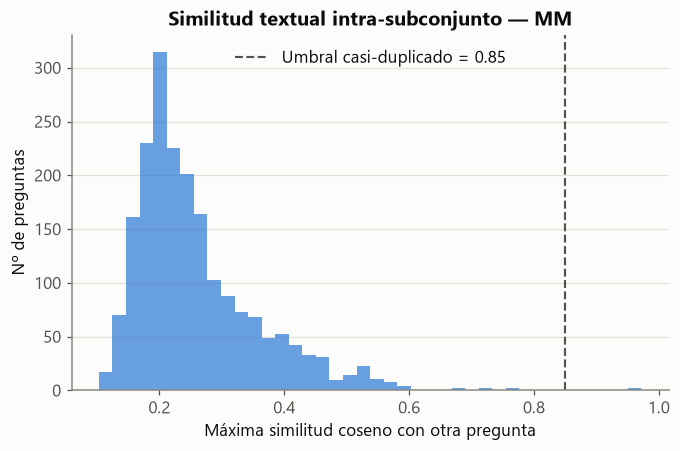

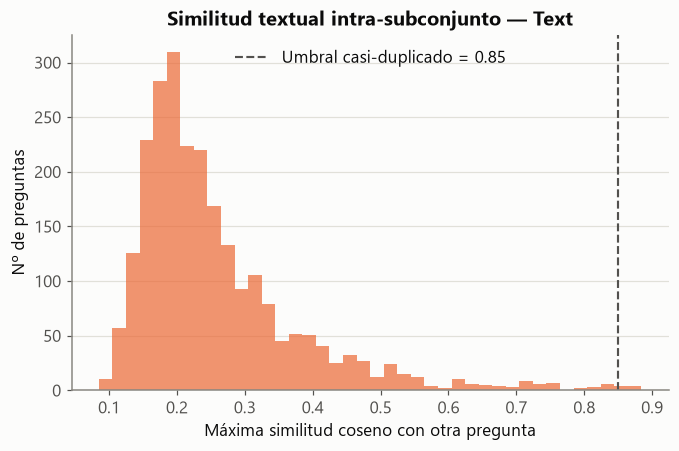

In [10]:
res_c3d = eda.c3_near_duplicates(dfs)
print("Grupos de duplicados exactos (texto):", res_c3d["n_exact_groups_total"])
print("Pares casi-duplicados (coseno >= %.2f):" % res_c3d["threshold"], res_c3d["n_near_pairs_total"])

**Lectura C.3.** Las preguntas de *Text* son más largas (10 opciones + viñetas clínicas),
lo que anticipa mayor coste de contexto en evaluación. No hay enunciados idénticos; los pares
de alta similitud quedan registrados en `outputs/tables/c3_near_duplicates.csv`.

## C.4 — Componente visual (solo MM)

Número de imágenes por pregunta, propiedades del conjunto (formato, resolución, aspecto,
tamaño, color/gris), huella en disco, hoja de contactos estratificada para anotación manual
de modalidad, y hashes (pHash + md5) con detección de duplicados exactos.

In [11]:
img_df = eda.build_image_table(dfs)   # usa caché generada por src/eda.py
print("Filas (referencias imagen-pregunta):", len(img_df),
      "| imágenes únicas:", img_df["file"].nunique())
img_df.head(4)

Filas (referencias imagen-pregunta): 2852 | imágenes únicas: 2852


,qid,file,body_system,question_type,medical_task,format,mode,width,height,area_px,aspect,filesize,is_gray,md5,phash
0,MM-0,MM-0-a.jpeg,Skeletal,Reasoning,Treatment,JPEG,L,713,735,524055,0.9701,16233,True,49f50bc30825ce6c20947e9b10833ec6,9cb3674c58cb31a5
1,MM-0,MM-0-b.jpeg,Skeletal,Reasoning,Treatment,JPEG,RGB,1500,1284,1926000,1.1682,90021,True,8bc36941326b707d52223ad566a3eec1,92b625c94a7ec879
2,MM-1,MM-1-a.png,Reproductive,Reasoning,Basic Science,PNG,RGB,149,382,56918,0.3901,49022,True,5ee5d4b2e2824e0ee0be061713aef227,d4ff7a94c44032c7
3,MM-1,MM-1-b.png,Reproductive,Reasoning,Basic Science,PNG,RGB,158,381,60198,0.4147,44171,True,a8df7004eeaaae374873fb79977c4134,c2e93d3696890be6


Multi-imagen: 20.9 % | máx imágenes: 6


,n_imagenes,n_preguntas,pct
0,1,1581,79.05
1,2,236,11.80
2,3,59,2.95
3,4,22,1.10
4,5,78,3.90
5,6,24,1.20


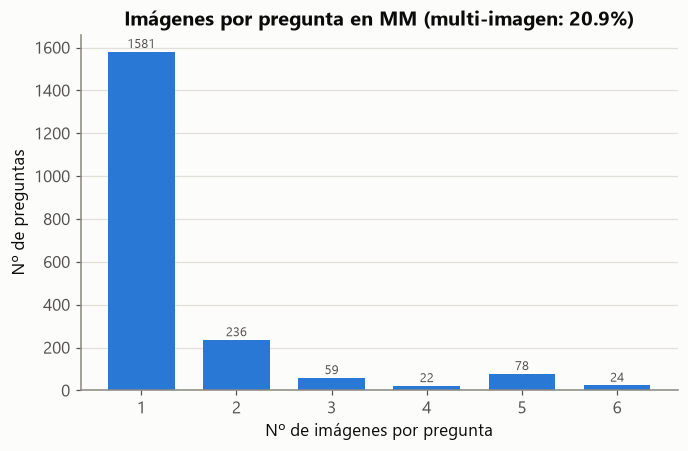

In [12]:
res_c4a = eda.c4_images_per_question(dfs)
print("Multi-imagen: %.1f %% | máx imágenes: %d" % (res_c4a["pct_multi"], res_c4a["max_images"]))
res_c4a["table"]

Resumen: {'n_imagenes': 2852, 'formatos': {'JPEG': 2304, 'PNG': 548}, 'color_n': 1144, 'gris_n': 1708, 'footprint_bytes': 524195022, 'footprint_mb': 524.2}


,width,height,area_px,aspect,filesize
count,2852.00,2852.00,2852.00,2852.00,2852.00
mean,763.85,646.82,655032.22,1.30,183799.10
std,474.38,431.75,804129.89,0.81,295012.49
min,117.00,34.00,10982.00,0.26,2726.00
5%,230.00,197.10,52104.60,0.62,8577.75
25%,394.00,364.00,145758.75,0.92,23667.00
50%,599.00,462.00,270000.00,1.22,67738.00
75%,1138.75,932.00,1002498.75,1.48,207751.25
95%,1500.00,1499.00,2215200.00,2.19,769805.55
max,4248.00,4000.00,9107712.00,17.90,3252374.00


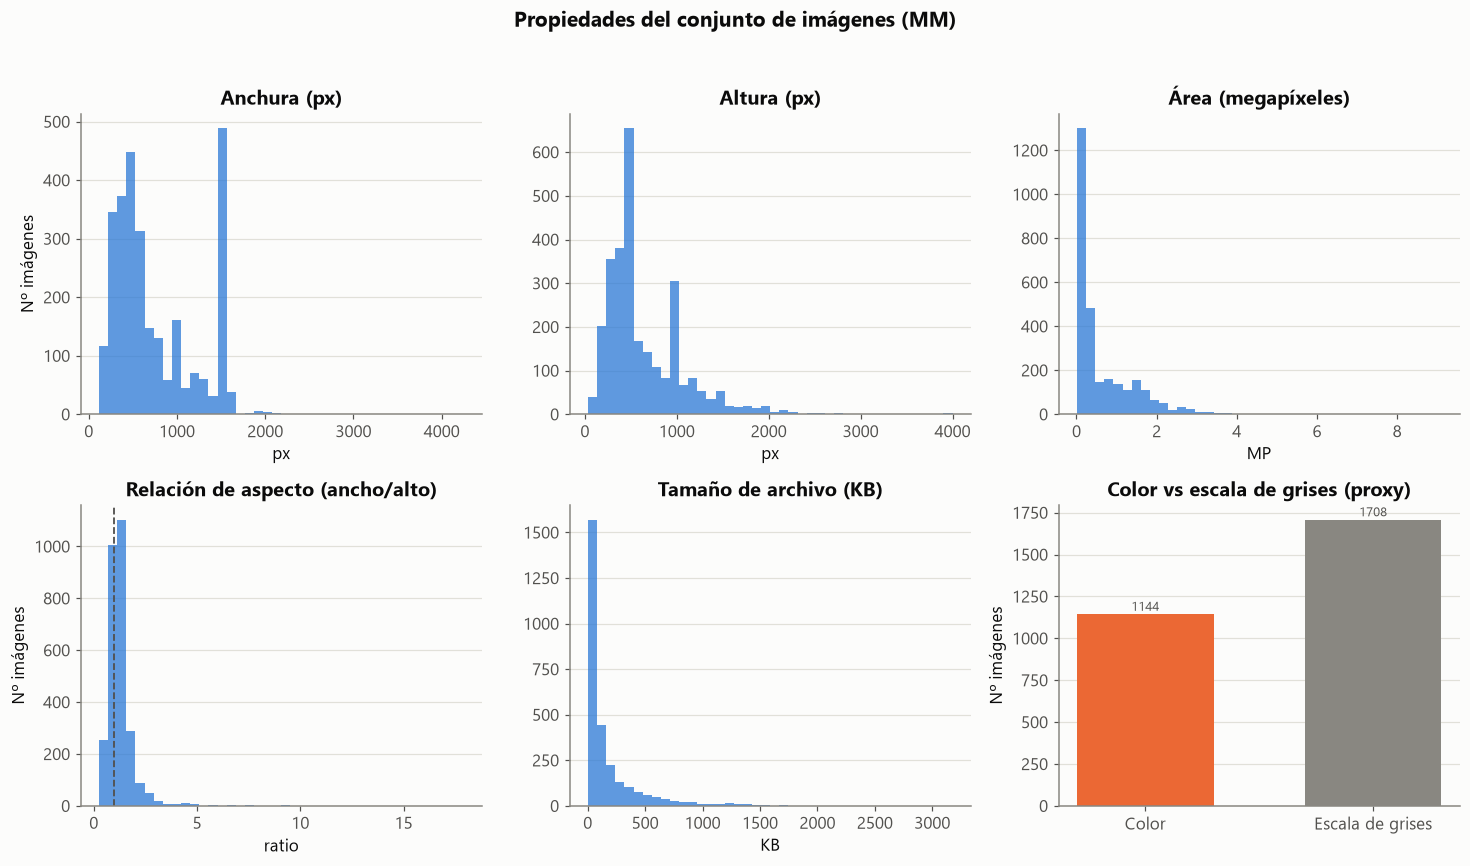

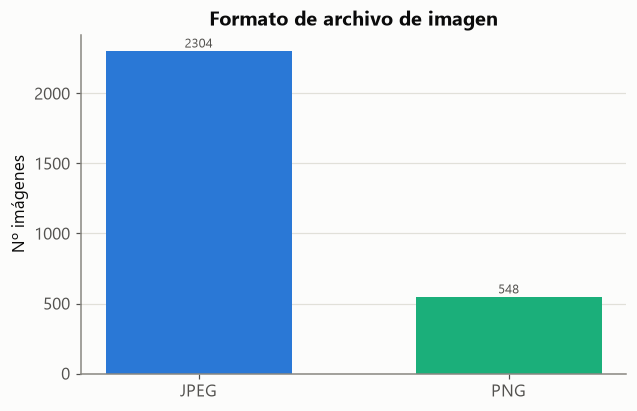

In [13]:
res_c4b = eda.c4_image_properties(img_df)
print("Resumen:", res_c4b["summary"])
res_c4b["dims"]

C:\Users\js834\OneDrive\Documentos\MedXpertQA\.venv\Lib\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Imágenes en la hoja de contactos: 36


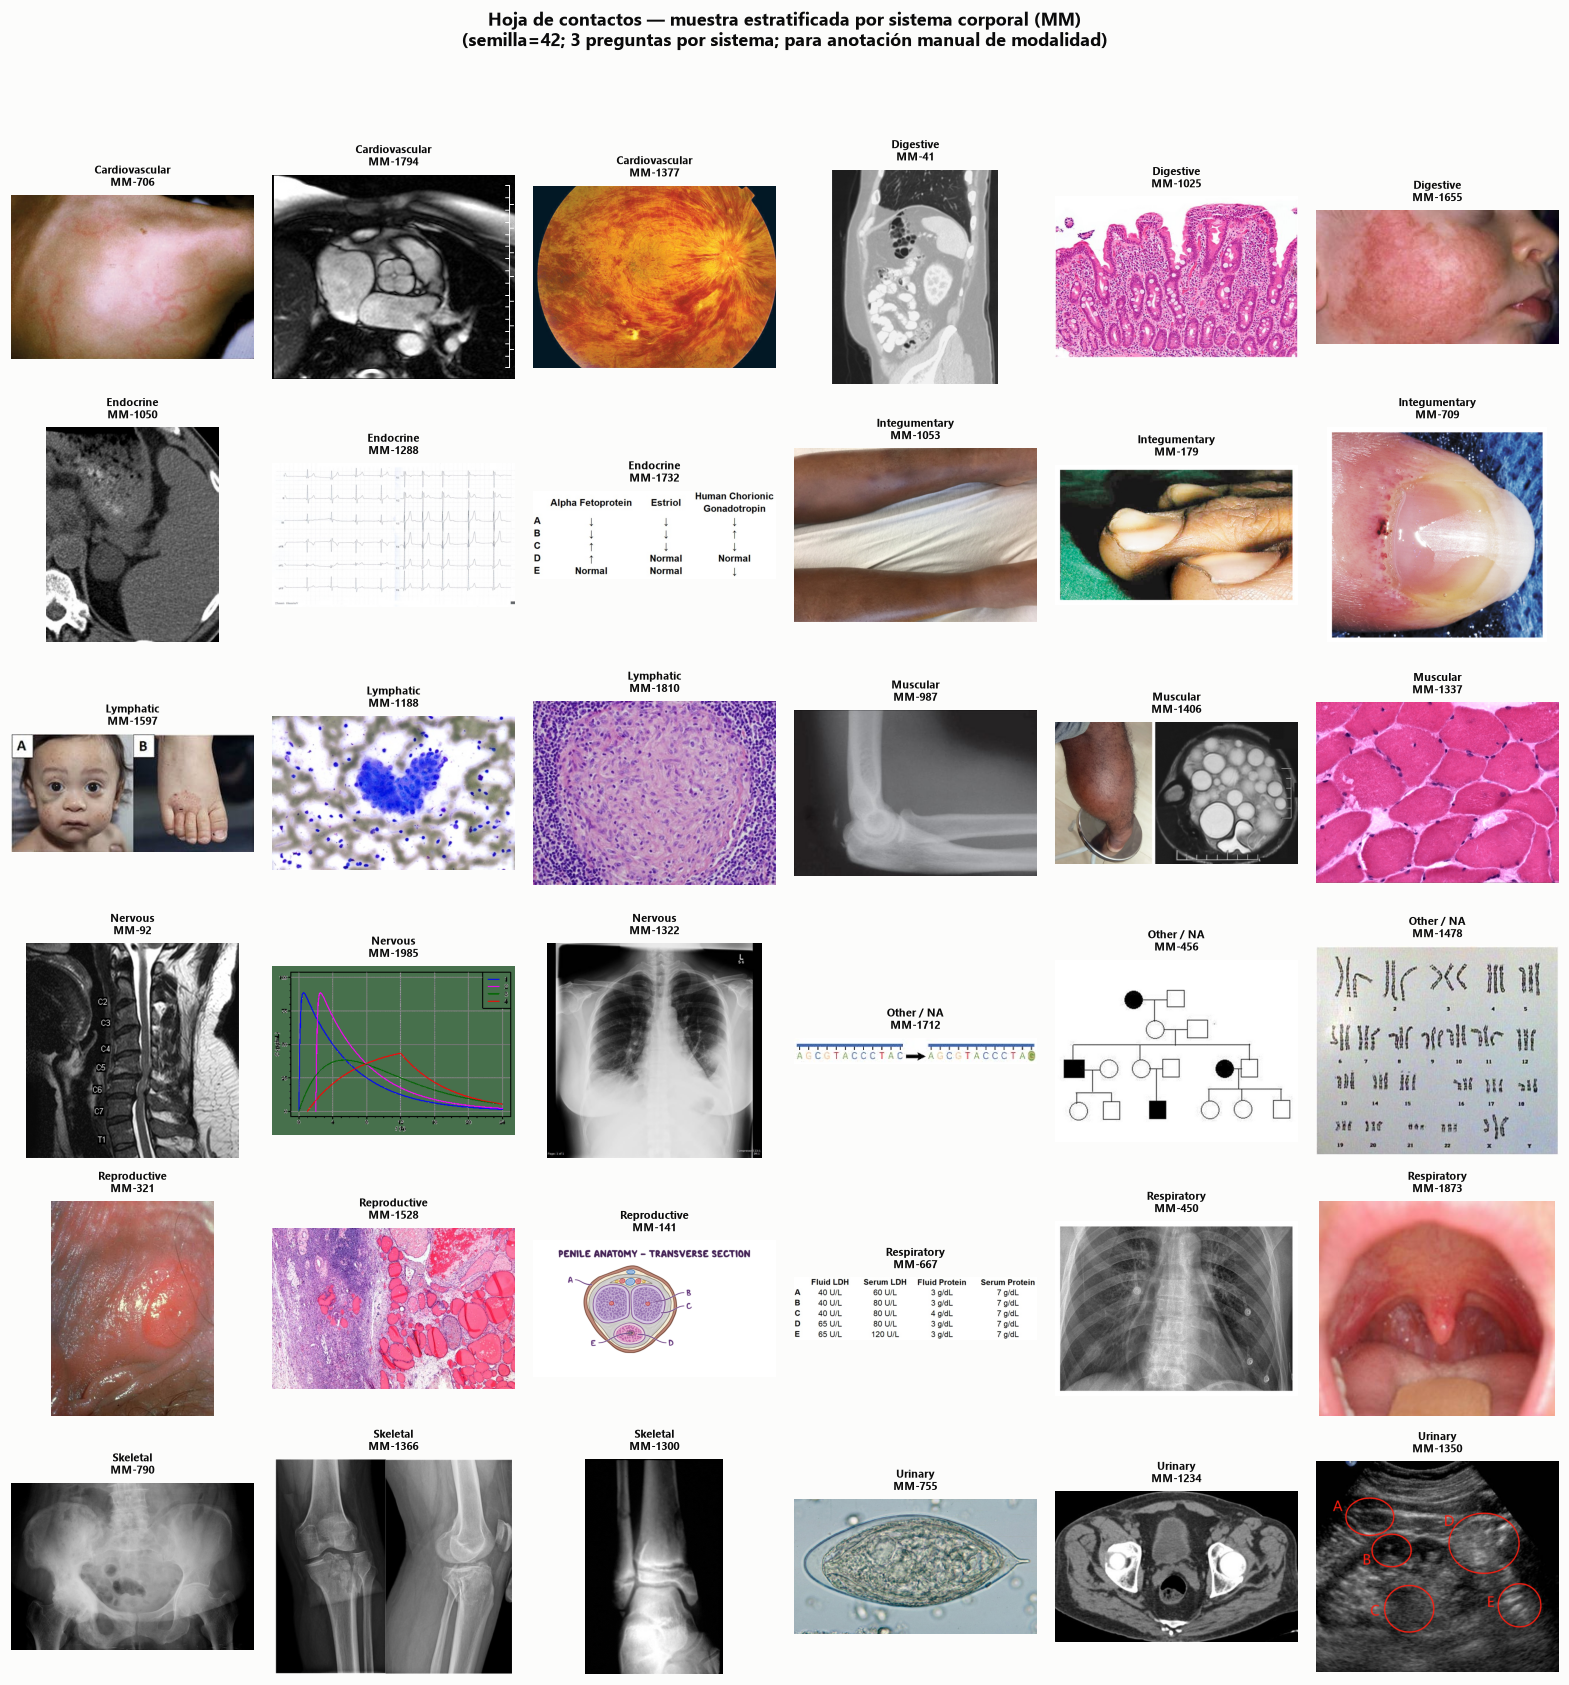

In [14]:
res_c4c = eda.c4_contact_sheet(dfs, img_df)
print("Imágenes en la hoja de contactos:", res_c4c["n"])

In [15]:
res_c4d = eda.c4_image_duplicates(img_df)
print("Grupos de imágenes exactamente duplicadas (md5) dentro de MM:",
      res_c4d["n_exact_dup_groups"])

Grupos de imágenes exactamente duplicadas (md5) dentro de MM: 35


In [16]:
# Cruce imagen↔texto: pares de preguntas que comparten imagen idéntica y su similitud textual
res_c4e = eda.c4_duplicate_question_pairs(dfs, img_df)
print("Pares que comparten imagen idéntica:", res_c4e["n_pairs"],
      "| casi-duplicadas también por texto (coseno>0.8):", res_c4e["n_near_dup_q"])
res_c4e["table"].head(8)

Pares que comparten imagen idéntica: 42 | casi-duplicadas también por texto (coseno>0.8): 1


,qid_a,qid_b,n_shared_images,text_cosine,near_dup_question
26,MM-121,MM-174,1,0.972,True
1,MM-158,MM-890,3,0.770,False
0,MM-1389,MM-267,3,0.247,False
11,MM-1316,MM-1658,2,0.398,False
23,MM-10,MM-1564,1,0.732,False
25,MM-121,MM-1564,1,0.703,False
27,MM-1564,MM-174,1,0.701,False
28,MM-21,MM-244,1,0.682,False


**Lectura C.4 y limitación de modalidad.** Una fracción relevante de MM es multi-imagen, lo
que condiciona la elección del VLM (soporte de varias imágenes por prompt). El proxy
color/gris sugiere una mezcla de modalidades, pero **el dataset no trae etiqueta de modalidad**
(radiografía/TAC/RM/histología/fotografía/ECG…): no se infiere ni se inventa. La hoja de
contactos (muestra estratificada por `body_system`, semilla fija) sirve para anotación manual.
Los hashes quedan guardados para futuros controles de fuga de datos.

## C.5 — Relación texto ↔ imagen (solo MM)

¿Qué fracción de preguntas menciona explícitamente la figura? ¿Cuántas tienen **opciones** que
remiten a figuras? Conclusión sobre el grado de acoplamiento multimodal.

Mención explícita de figura: 78.8 %
Opciones que refieren figura: 5.0 %


,id,question
0,MM-0,"A 26-year-old man falls from a ladder, landing..."
2,MM-2,A 21-year-old African-American male with recen...


,id,question
1,MM-1,This patient presents for mammographic needle ...
9,MM-9,A patient with a history of invasive breast ca...


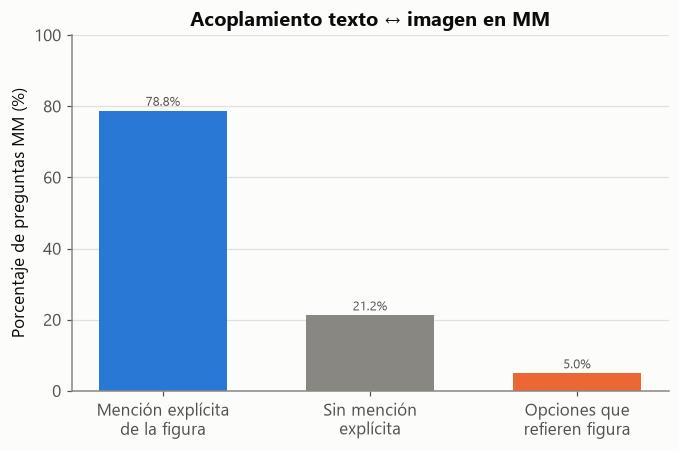

In [17]:
res_c5 = eda.c5_text_image_coupling(dfs)
print("Mención explícita de figura: %.1f %%" % res_c5["pct_explicit"])
print("Opciones que refieren figura: %.1f %%" % res_c5["pct_opt"])
display(res_c5["ex_explicit"].head(2))
res_c5["ex_implicit"].head(2)

**Conclusión de acoplamiento multimodal.** Aunque no todas las preguntas nombran la figura,
todas las de MM traen imagen y una parte sustancial es visualmente dependiente. El subconjunto
MM **no** es resoluble de forma fiable solo con texto: la imagen es central, no accesoria.

## Informes y entregables transversales

Se regeneran, a partir de los resultados calculados arriba: `01_eda.md` (informe integrado),
`data_card.md` (ficha del dataset), `indice_figuras_tablas.md` (índice navegable de figuras y
tablas) y `hallazgos_one_pager.md` (resumen ejecutivo de una página).

In [18]:
res = {"c1": res_c1, "c1x": res_c1x, "c1o": res_c1o, "c2": res_c2,
       "c3": res_c3, "c3d": res_c3d, "c4a": res_c4a, "c4b": res_c4b,
       "c4c": res_c4c, "c4d": res_c4d, "c4e": res_c4e, "c5": res_c5}
p1 = eda.build_report(res, dfs)
p2 = eda.build_data_card(res, dfs)
p3 = eda.build_figure_table_index()
p4 = eda.build_onepager(res, dfs)
print("Escritos:", ", ".join(p.name for p in (p1, p2, p3, p4)))

Escritos: 01_eda.md, data_card.md, indice_figuras_tablas.md, hallazgos_one_pager.md
